In [1]:
import joblib

modelo = joblib.load("../predictive-model/modelo_rf.pkl")

In [2]:
# Carregar o mesmo dataset bruto usado no treinamento
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_modelo = pd.read_csv("../predictive-model/df_modelo_30dias.csv")
df_modelo["data"] = pd.to_datetime(df_modelo["data"])
df_modelo["hora"] = df_modelo["data"].dt.hour

def periodo_do_dia(hora):
    if 5 <= hora < 12:
        return "manhã"
    elif 12 <= hora < 18:
        return "tarde"
    elif 18 <= hora < 24:
        return "noite"
    else:
        return "madrugada"

df_modelo["periodo"] = df_modelo["hora"].apply(periodo_do_dia)
le_titulo = LabelEncoder()
le_proximo = LabelEncoder()
le_periodo = LabelEncoder()
df_modelo["titulo_encoded"] = le_titulo.fit_transform(df_modelo["titulo"])
df_modelo["proximo_encoded"] = le_proximo.fit_transform(df_modelo["proximo_video"])
df_modelo["periodo_encoded"] = le_periodo.fit_transform(df_modelo["periodo"])

# Usar as mesmas features do treinamento
X = df_modelo[["titulo_encoded", "periodo_encoded"]]
y = df_modelo["proximo_encoded"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [3]:
# y_test já foi criado acima, não é necessário recarregar
# y_test = pd.read_csv("../predictive-model/Y_test.csv")
# Mantém a variável y_test criada no split

In [4]:
n = min(1000, len(X_test))

X_test_small = X_test.sample(n, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

In [5]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    modelo,
    X_test_small,
    y_test_small,
    n_repeats=5,
    scoring="f1_weighted",
    random_state=42
)

ValueError: feature_names mismatch: ['qtd_videos_curtidos', 'media_views'] ['titulo_encoded', 'periodo_encoded']
expected qtd_videos_curtidos, media_views in input data
training data did not have the following fields: periodo_encoded, titulo_encoded

In [ ]:
import pandas as pd
import numpy as np

importances = pd.Series(
    result.importances_mean,
    index=X_test.columns
)

importances = importances.sort_values(ascending=True)

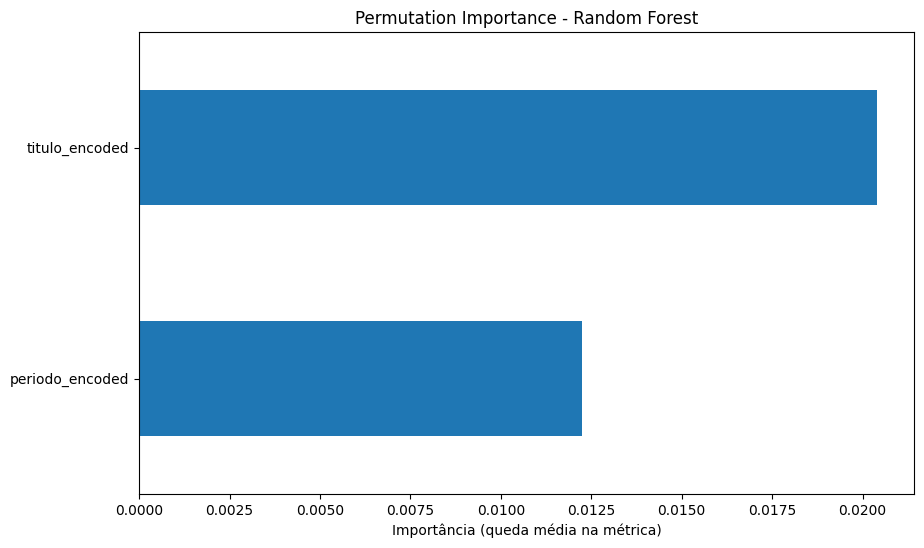

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
importances.plot(kind="barh")
plt.xlabel("Importância (queda média na métrica)")
plt.title("Permutation Importance - Random Forest")
plt.show()

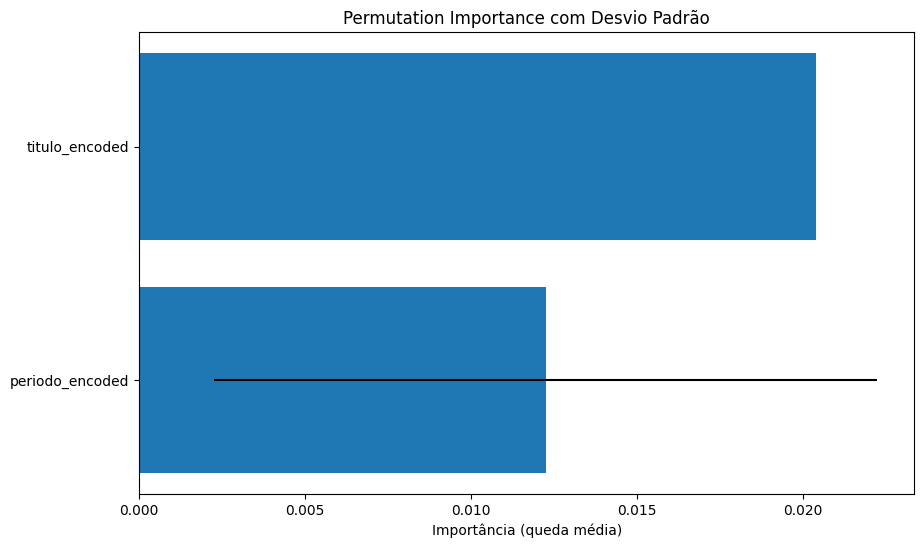

In [ ]:
sorted_idx = importances.index

plt.figure(figsize=(10, 6))
plt.barh(
    sorted_idx,
    result.importances_mean[np.argsort(result.importances_mean)],
    xerr=result.importances_std[np.argsort(result.importances_mean)]
)
plt.xlabel("Importância (queda média)")
plt.title("Permutation Importance com Desvio Padrão")
plt.show()